In [23]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, List, Annotated, Literal
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from dotenv import load_dotenv

In [9]:

load_dotenv()

llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    task="text-generation"
)

model = ChatHuggingFace(llm=llm)

In [10]:
class chat_state(TypedDict):
    msg : Annotated[List[BaseMessage], add_messages]

In [11]:
def chat(state: chat_state) -> chat_state:

    result = model.invoke(state['msg'])

    return {'msg' : [result]}

    

In [14]:
graph = StateGraph(chat_state)

graph.add_node('generate_chat', chat)

graph.add_edge(START, 'generate_chat')
graph.add_edge('generate_chat', END)

chatbot = graph.compile()

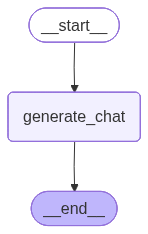

In [16]:
chatbot

In [17]:
result = chatbot.invoke({'msg': HumanMessage(content="Generate an essay on Dehradun!!!")})

In [18]:
result

{'msg': [HumanMessage(content='Generate an essay on Dehradun!!!', additional_kwargs={}, response_metadata={}, id='acf1090a-f169-4dd6-9fa2-a0c539433f72'),
  AIMessage(content="**The Hidden Gem of Dehradun: A City of Natural Beauty and Cultural Richness**\n\nNestled in the foothills of the Himalayas, Dehradun is a city that has captivated the hearts of many with its breathtaking natural beauty, rich cultural heritage, and warm hospitality. Located in the state of Uttarakhand, India, Dehradun has evolved from a small hill station into a vibrant metropolis, which has become a hub for education, healthcare, and tourism.\n\n**Natural Beauty**\n\nSurrounded by lush forests, rolling hills, and majestic mountains, Dehradun is a nature lover's paradise. The city is home to numerous trekking trails, offering breathtaking views of the Himalayas. The nearby Mussoorie and Doon Valley provide a serene escape from the city's hustle and bustle, making it an ideal destination for those seeking a tranqui

In [21]:
result['msg'][-1].content

"**The Hidden Gem of Dehradun: A City of Natural Beauty and Cultural Richness**\n\nNestled in the foothills of the Himalayas, Dehradun is a city that has captivated the hearts of many with its breathtaking natural beauty, rich cultural heritage, and warm hospitality. Located in the state of Uttarakhand, India, Dehradun has evolved from a small hill station into a vibrant metropolis, which has become a hub for education, healthcare, and tourism.\n\n**Natural Beauty**\n\nSurrounded by lush forests, rolling hills, and majestic mountains, Dehradun is a nature lover's paradise. The city is home to numerous trekking trails, offering breathtaking views of the Himalayas. The nearby Mussoorie and Doon Valley provide a serene escape from the city's hustle and bustle, making it an ideal destination for those seeking a tranquil retreat. The picturesque River Ganga nearby adds to the city's natural charm, offering a scenic view of the river and its surroundings.\n\n**Cultural Richness**\n\nDehradun

In [ ]:
while True:

    user_input =  input("User: ")

    print("User: ", user_input)

    if user_input.strip().lower() in ['bye', 'exit', 'okkk']:
        break
     
    result = chatbot.invoke({'msg':HumanMessage(content=user_input)})

    print("Assistant: ", result['msg'][-1].content)

Assistant:  hlw, how can i help you today?
Assistant:  Hello AKR, it's nice to meet you. Is there something I can help you with or would you like to chat about something in particular?
Assistant:  The capital of India is New Delhi.
Assistant:  This is the beginning of our conversation, and I'm a large language model, I don't have the ability to remember past conversations or store information about individual users. Each time you interact with me, it's a new conversation. If you'd like to share your name, I'd be happy to learn it for our conversation, though!
Assistant:  Goodbye.
Assistant:  It seems like you're asking for a clear or a "clear" topic. Could you please provide more context or clarify what you would like to know about being clear? Some possible topics related to "clear" could be:

1. Clear (band): A British rock band known for their music and performances.
2. Clear (clarity): Describing something as being transparent or free from obstacles.
3. Clear (communication): How t